<h2>PROJETO I - HOUSING CALIFORNIA<h3>

### 1. **Resumo**

#### 1.1 tipo: Análise exploratória + modelo 
#### 1.2 dados: [California Housing Prices](https://www.kaggle.com/code/ahmedmahmoud16/california-housing-prices) 
#### 1.3 Objetivo geral: Estimar valores médios das residencias por região
<br>

### 2. **Contexto do negócio**

#### 2.1 **Problema:** A empresa necessita identificar qual região é mais cara por valores médios de residência x região
#### 2.2 **Objetivo:** Encontrar as features correlacionadas com a feature median_housing_value, para o modelo ser o mais preciso em sua previsão.**obs: Verificar se regressão linear é suficiente!**
#### 2.3 ***Questionamento:** O que explica o preço das casas? 
Onde as casas são mais caras?
<br>
Quem mora nessas regiões?
<br>
Que características da casa importam de verdade?

<br>

### 3. **MODELO: Regressão Linear**

#### 3.1 Regressão linear estima a relação entre variável dependente **(y)** e uma ou mais varíaveis independentes **(x)**
#### 3.2 **Quando usar:** <br>-Prever valores continuos<br> -Tendência<br> -Relação direta entre os dados<br>
#### 3.3 **Quando não usar:** <br>-Muitos outliers<br> -Sensível a escala<br> -Relação complexa ou não linear<br>


### 4. **Anotações**

#### Novas colunas criadas
#### features fortes para o modelo (median_income, ocean_proximity, rooms_p_households)
#### median_house_value tem teto artifical de 500k

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## 1. IMPORTANDO OS DADOS

In [2]:

df = pd.read_csv(r'C:\Users\ryan\datasets\housing.csv')
pd.options.display.float_format = "{:,.2f}".format
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.00,880.00,129.00,322.00,126.00,8.33,"452,600.00",NEAR BAY
1,-122.22,37.86,21.00,"7,099.00","1,106.00","2,401.00","1,138.00",8.30,"358,500.00",NEAR BAY
2,-122.24,37.85,52.00,"1,467.00",190.00,496.00,177.00,7.26,"352,100.00",NEAR BAY
3,-122.25,37.85,52.00,"1,274.00",235.00,558.00,219.00,5.64,"341,300.00",NEAR BAY
4,-122.25,37.85,52.00,"1,627.00",280.00,565.00,259.00,3.85,"342,200.00",NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.00,"1,665.00",374.00,845.00,330.00,1.56,"78,100.00",INLAND
20636,-121.21,39.49,18.00,697.00,150.00,356.00,114.00,2.56,"77,100.00",INLAND
20637,-121.22,39.43,17.00,"2,254.00",485.00,"1,007.00",433.00,1.70,"92,300.00",INLAND
20638,-121.32,39.43,18.00,"1,860.00",409.00,741.00,349.00,1.87,"84,700.00",INLAND


## 2. TRATAMENTO DOS DADOS

In [3]:
#Eliminando coluna string para calcular
df_num = df.select_dtypes(include="number")
df_num

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.23,37.88,41.00,880.00,129.00,322.00,126.00,8.33,"452,600.00"
1,-122.22,37.86,21.00,"7,099.00","1,106.00","2,401.00","1,138.00",8.30,"358,500.00"
2,-122.24,37.85,52.00,"1,467.00",190.00,496.00,177.00,7.26,"352,100.00"
3,-122.25,37.85,52.00,"1,274.00",235.00,558.00,219.00,5.64,"341,300.00"
4,-122.25,37.85,52.00,"1,627.00",280.00,565.00,259.00,3.85,"342,200.00"
...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.00,"1,665.00",374.00,845.00,330.00,1.56,"78,100.00"
20636,-121.21,39.49,18.00,697.00,150.00,356.00,114.00,2.56,"77,100.00"
20637,-121.22,39.43,17.00,"2,254.00",485.00,"1,007.00",433.00,1.70,"92,300.00"
20638,-121.32,39.43,18.00,"1,860.00",409.00,741.00,349.00,1.87,"84,700.00"


In [4]:
df_num.describe().round(2)
#Valores arredondados com round(2)

#COUNT = quantidade de valores não nulos (total_bedrooms está faltando) afeta no modelo
#MEAN = média dos valores (cuidado, sensivel a outlier)
#STD = Desvio padrão dos valores 
#MIN = Menor valor
#25% =  1/4
#50% = Mediana
#75% =3/4
#max = Máximo (Pode possuir outliers)

#OBS: mean > median = Assimetria a direita

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,"20,640.00","20,640.00","20,640.00","20,640.00","20,433.00","20,640.00","20,640.00","20,640.00","20,640.00"
mean,-119.57,35.63,28.64,"2,635.76",537.87,"1,425.48",499.54,3.87,"206,855.82"
std,2.00,2.14,12.59,"2,181.62",421.39,"1,132.46",382.33,1.90,"115,395.62"
min,-124.35,32.54,1.00,2.00,1.00,3.00,1.00,0.50,"14,999.00"
25%,-121.80,33.93,18.00,"1,447.75",296.00,787.00,280.00,2.56,"119,600.00"
50%,-118.49,34.26,29.00,"2,127.00",435.00,"1,166.00",409.00,3.53,"179,700.00"
75%,-118.01,37.71,37.00,"3,148.00",647.00,"1,725.00",605.00,4.74,"264,725.00"
max,-114.31,41.95,52.00,"39,320.00","6,445.00","35,682.00","6,082.00",15.00,"500,001.00"


In [5]:
#Valores nulos
df_num.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
dtype: int64

In [ ]:
#Alterando os 207 valores nulos de total_bedrooms para mediana  

df_num["total_bedrooms"] = df_num["total_bedrooms"].fillna(
    df_num["total_bedrooms"].median())
    
df_num.isnull().sum()


longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
dtype: int64

## 3. ANÁLISE E ENGENHARIA 

### 3.1 ENGENHARIA DE FEATURE

In [7]:
#Criar novas features para desenvolver nossa análise e alimentar melhor o modelo
#population_p_households = média de pessoas por casa - comum (2-4)
#rooms_p_households = média de comodos por casa - comum (2-4)
#bedrooms_p_households = média de quartos por casa - comum (2-4)

df_num["population_p_households"] = df_num["population"] / df_num["households"]
df_num["rooms_p_households"] = df_num["total_rooms"] / df_num["households"]
df_num["bedrooms_p_households"] = df_num["total_bedrooms"] / df_num["households"]
df_num


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,population_p_households,rooms_p_households,bedrooms_p_households
0,-122.23,37.88,41.00,880.00,129.00,322.00,126.00,8.33,"452,600.00",2.56,6.98,1.02
1,-122.22,37.86,21.00,"7,099.00","1,106.00","2,401.00","1,138.00",8.30,"358,500.00",2.11,6.24,0.97
2,-122.24,37.85,52.00,"1,467.00",190.00,496.00,177.00,7.26,"352,100.00",2.80,8.29,1.07
3,-122.25,37.85,52.00,"1,274.00",235.00,558.00,219.00,5.64,"341,300.00",2.55,5.82,1.07
4,-122.25,37.85,52.00,"1,627.00",280.00,565.00,259.00,3.85,"342,200.00",2.18,6.28,1.08
...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.00,"1,665.00",374.00,845.00,330.00,1.56,"78,100.00",2.56,5.05,1.13
20636,-121.21,39.49,18.00,697.00,150.00,356.00,114.00,2.56,"77,100.00",3.12,6.11,1.32
20637,-121.22,39.43,17.00,"2,254.00",485.00,"1,007.00",433.00,1.70,"92,300.00",2.33,5.21,1.12
20638,-121.32,39.43,18.00,"1,860.00",409.00,741.00,349.00,1.87,"84,700.00",2.12,5.33,1.17


In [8]:
#verificando se há valores a baixo de 1
df_num[df_num["population_p_households"] < 1].sort_values(by="population_p_households",  ascending=False)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,population_p_households,rooms_p_households,bedrooms_p_households
19522,-121.00,37.65,17.00,484.00,202.00,198.00,204.00,0.68,"187,500.00",0.97,2.37,0.99
5342,-118.44,34.04,16.00,18.00,6.00,3.00,4.00,0.54,"350,000.00",0.75,4.50,1.50
11849,-121.00,39.75,8.00,"1,116.00",214.00,27.00,39.00,2.59,"83,000.00",0.69,28.62,5.49


### 3.2 Análise estatística e dados

In [9]:
df_filtro = df_num[df_num["median_house_value"]<500000]
df_corr = df_filtro.corr(method="spearman")
df_corr

#Analisando correlação sem o teto de 500k
#MEDIAN_HOUSE_VALUE = median_income(0.65) / rooms_p_households(0,22) / ocean_proximity (string mas é feature necessária)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,population_p_households,rooms_p_households,bedrooms_p_households
longitude,1.00,-0.88,-0.14,0.05,0.07,0.13,0.06,0.00,-0.06,0.18,-0.04,0.00
latitude,-0.88,1.00,0.03,-0.02,-0.06,-0.13,-0.08,-0.08,-0.17,-0.17,0.14,0.06
housing_median_age,-0.14,0.03,1.00,-0.37,-0.31,-0.28,-0.29,-0.18,0.05,-0.00,-0.26,-0.12
total_rooms,0.05,-0.02,-0.37,1.00,0.91,0.82,0.91,0.27,0.21,-0.14,0.26,0.08
total_bedrooms,0.07,-0.06,-0.31,0.91,1.00,0.87,0.97,0.01,0.11,-0.16,-0.06,0.21
population,0.13,-0.13,-0.28,0.82,0.87,1.00,0.90,0.03,0.04,0.24,-0.09,0.01
households,0.06,-0.08,-0.29,0.91,0.97,0.90,1.00,0.05,0.14,-0.14,-0.10,0.05
median_income,0.00,-0.08,-0.18,0.27,0.01,0.03,0.05,1.00,0.65,-0.03,0.62,-0.26
median_house_value,-0.06,-0.17,0.05,0.21,0.11,0.04,0.14,0.65,1.00,-0.23,0.22,-0.15
population_p_households,0.18,-0.17,-0.00,-0.14,-0.16,0.24,-0.14,-0.03,-0.23,1.00,0.01,-0.12


In [10]:
#Quais features possuem a MÉDIA > MEDIANA
#MÉDIA > MEDIANA = ASSIMETRIA POSITIVA
#OBS: ALGUMAS FEATURES É COMUM QUASE SEMPRE TEM ASSIMETRIA (IGNORAR)
df_median = df_num.median()
df_mean = df_num.mean()
df_mean > df_median

longitude                  False
latitude                    True
housing_median_age         False
total_rooms                 True
total_bedrooms              True
population                  True
households                  True
median_income               True
median_house_value          True
population_p_households     True
rooms_p_households          True
bedrooms_p_households       True
dtype: bool

## 4. Visualizações

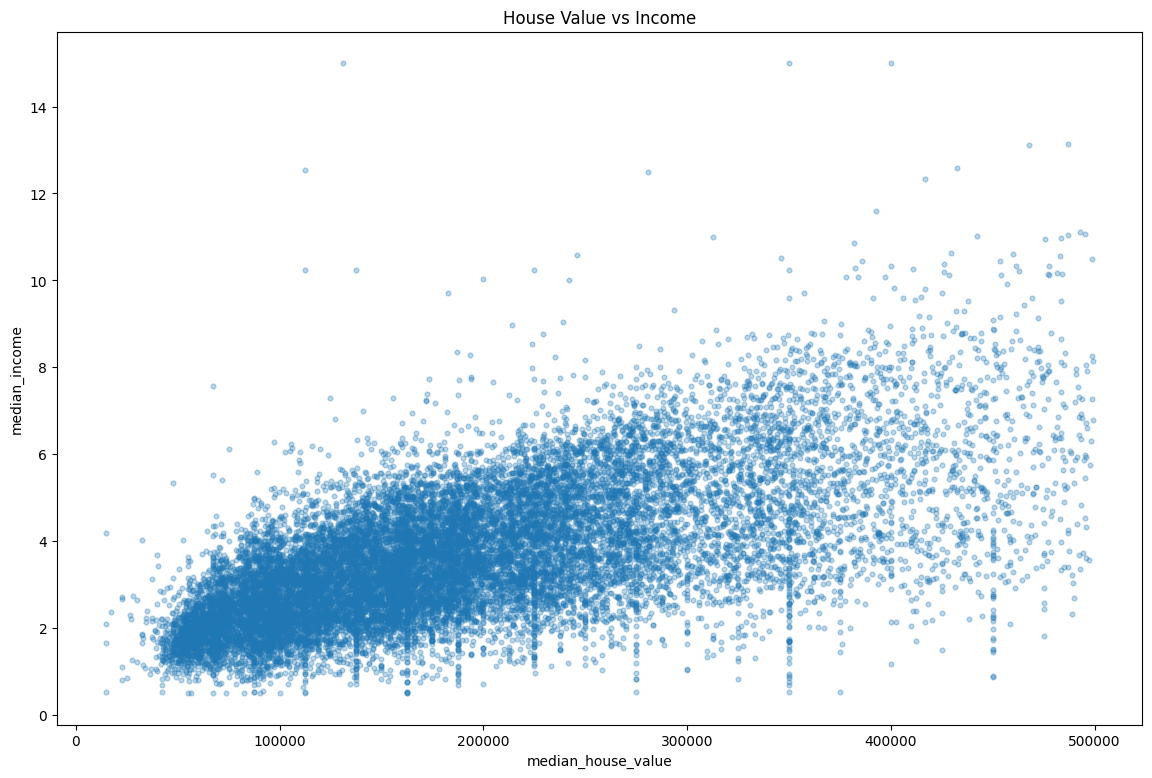

In [11]:
x = df_filtro["median_house_value"]
y = df_filtro["median_income"]

plt.figure(figsize=(14, 9))
plt.scatter(x, y, s=12, alpha=0.3)
plt.xlabel("median_house_value")
plt.ylabel("median_income")
plt.title("House Value vs Income")
plt.show()

#OBS: DATASET POSSUI TETO E OUTLIER, retirei o teto artificial
#Valores se concentram mais inicialmente média entre 20/40k por ano e casas de 100/200k


In [12]:
df[df["median_house_value"]<100000][["median_income","median_house_value"]].sort_values(by="median_house_value" ,ascending=True)
#identificando valores a baixo dos 100k



,median_income,median_house_value
2521,1.66,"14,999.00"
19802,0.54,"14,999.00"
9188,4.19,"14,999.00"
2799,2.10,"14,999.00"
5887,2.37,"17,500.00"
...,...,...
5214,2.33,"99,800.00"
3154,3.26,"99,800.00"
5095,2.07,"99,800.00"
20084,3.19,"99,800.00"


<Figure size 1000x600 with 0 Axes>

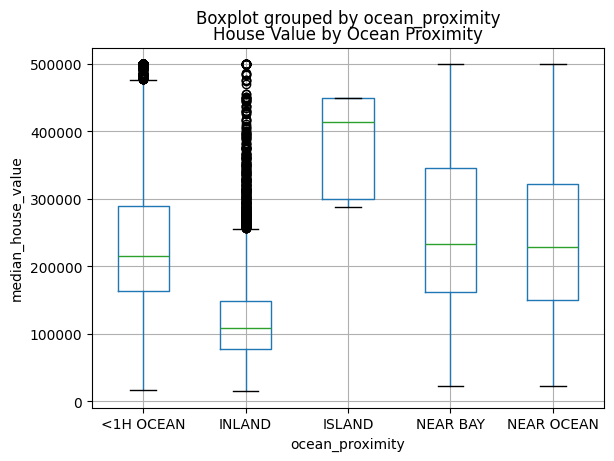

In [13]:
plt.figure(figsize=(10, 6))
df.boxplot(column="median_house_value", by="ocean_proximity")
plt.title("House Value by Ocean Proximity")
plt.xlabel("ocean_proximity")
plt.ylabel("median_house_value")
plt.show()

#Boxplot criado para identificar relação e visualizar de melhor forma cada categoria de geolocalização
#1H OCEAN = casas entre 180/290k
#INLAND = INTERIOR, casas mais baratas 80/150k
#island ocen.. = CASAS EM ILHAS, mais caras 300/450k
#NEAR BAY = BAÍA, 2 mais caro, cidade grande, ao lado do mar 160/350k
#NEAR OCEAN = EM FRENTE AO MAR, casas voltadas ao oceano normalmente e cidades turisticas 150/330k

In [14]:
df.groupby("ocean_proximity")["median_house_value"].describe()

,count,mean,std,min,25%,50%,75%,max
ocean_proximity,,,,,,,,
<1H OCEAN,"9,136.00","240,084.29","106,124.29","17,500.00","164,100.00","214,850.00","289,100.00","500,001.00"
INLAND,"6,551.00","124,805.39","70,007.91","14,999.00","77,500.00","108,500.00","148,950.00","500,001.00"
ISLAND,5.00,"380,440.00","80,559.56","287,500.00","300,000.00","414,700.00","450,000.00","450,000.00"
NEAR BAY,"2,290.00","259,212.31","122,818.54","22,500.00","162,500.00","233,800.00","345,700.00","500,001.00"
NEAR OCEAN,"2,658.00","249,433.98","122,477.15","22,500.00","150,000.00","229,450.00","322,750.00","500,001.00"


## 5. Modelagem

### 5.1 modelo com median_income

##### Testando com apenas 1 feature, mais correlacionada 0.65

In [15]:
X1 = df[["median_income"]]
Y = df["median_house_value"]


In [16]:
X_train, X_test, Y_train, Y_test = train_test_split(X1, Y, test_size=0.2, random_state=42)

In [17]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [18]:
model1 = LinearRegression()

model1.fit(X_train_scaled, Y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [19]:
Y_pred = model1.predict(X_test_scaled)


In [20]:
from sklearn.metrics import r2_score, mean_absolute_error

r2 = r2_score(Y_test, Y_pred)
mae = mean_absolute_error(Y_test, Y_pred)

print("R²:", r2)
print("MAE:", mae)


R²: 0.45885918903846656
MAE: 62990.86530093761


In [21]:
model1.coef_
model1.intercept_


np.float64(207194.6937378876)

In [26]:
Y = df["median_house_value"]
X2 = df_num.drop("median_house_value", axis=1)

In [27]:
X_train, X_test, Y_train, Y_test = train_test_split(X2, Y, test_size=0.2, random_state=42)

In [28]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [29]:
model1 = LinearRegression()

model1.fit(X_train_scaled, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [30]:
Y_pred = model1.predict(X_test_scaled)


In [31]:
from sklearn.metrics import r2_score, mean_absolute_error

r2 = r2_score(Y_test, Y_pred)
mae = mean_absolute_error(Y_test, Y_pred)

print("R²:", r2)
print("MAE:", mae)


R²: 0.5584724322801279
MAE: 52419.31038939387


In [32]:
model1.coef_
model1.intercept_


np.float64(207194.6937378881)